In [175]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [176]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [177]:
df = df[['Age','EstimatedSalary','Purchased']]
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [178]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [179]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [180]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [181]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [182]:
X_scaled[1:11]

array([[0.4047619 , 0.03703704],
       [0.19047619, 0.20740741],
       [0.21428571, 0.31111111],
       [0.02380952, 0.45185185],
       [0.21428571, 0.31851852],
       [0.21428571, 0.51111111],
       [0.33333333, 1.        ],
       [0.16666667, 0.13333333],
       [0.4047619 , 0.37037037],
       [0.19047619, 0.48148148]])

In [183]:
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,stratify=y,random_state=42)

In [184]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [185]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\nasrullah\.conda\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [186]:
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## **1. Batch Gradient Descent**

In [187]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [188]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])

In [189]:
%%time
history = model.fit(X_train,y_train,epochs=30,verbose=1,batch_size=400,validation_split=0.2)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6172 - loss: 0.6985 - val_accuracy: 0.7500 - val_loss: 0.6767
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.6172 - loss: 0.6960 - val_accuracy: 0.7500 - val_loss: 0.6752
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6172 - loss: 0.6942 - val_accuracy: 0.7500 - val_loss: 0.6740
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.6172 - loss: 0.6927 - val_accuracy: 0.7500 - val_loss: 0.6729
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.6172 - loss: 0.6914 - val_accuracy: 0.7500 - val_loss: 0.6719
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.6172 - loss: 0.6902 - val_accuracy: 0.7500 - val_loss: 0.6709
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.6172 - loss: 0.6891 - val_accuracy: 0.7500 - val_loss: 0.6700
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.6172 - loss: 0.6881 - val_accuracy: 0.7500 - val_loss: 0.

[]

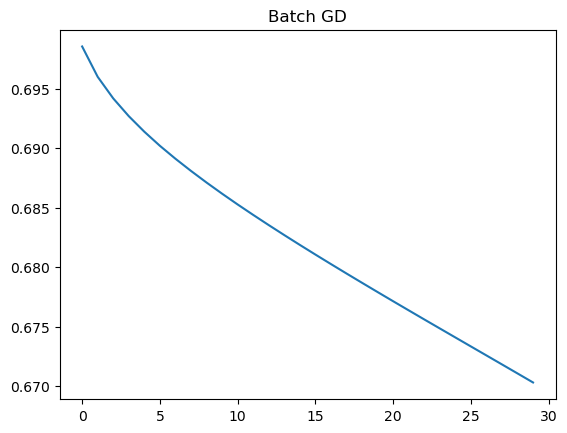

In [190]:
plt.plot(history.history['loss'])
plt.title("Batch GD")
plt.plot()

## **2. Stochastic Gradient Descent**

In [191]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [192]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])

In [193]:
%%time
history = model.fit(X_train,y_train,epochs=30,verbose=1,batch_size=1,validation_split=0.2)

Epoch 1/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6250 - loss: 0.6878 - val_accuracy: 0.7500 - val_loss: 0.6584
Epoch 2/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6070 - loss: 0.6681 - val_accuracy: 0.7500 - val_loss: 0.6182
Epoch 3/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6847 - loss: 0.6197 - val_accuracy: 0.8125 - val_loss: 0.5942
Epoch 4/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7313 - loss: 0.5988 - val_accuracy: 0.8125 - val_loss: 0.5508
Epoch 5/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7944 - loss: 0.5573 - val_accuracy: 0.8594 - val_loss: 0.5113
Epoch 6/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8102 - loss: 0.5280 - val_accuracy: 0.8281 - val_loss: 0.4645
Epoch 7/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8363 - loss: 0.4673 - val_accuracy: 0.8438 - val_loss: 0.4510
Epoch 8/30
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8513 - loss: 0.4256 - val_accuracy: 0.

[]

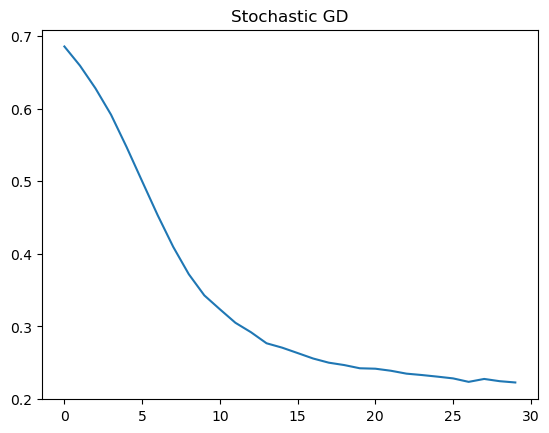

In [194]:
plt.plot(history.history['loss'])
plt.title("Stochastic GD")
plt.plot()

## **3. Mini Batch Gradient Descent**

In [195]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [196]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])

In [197]:
%%time
history = model.fit(X_train,y_train,epochs=30,verbose=1,batch_size=50,validation_split=0.2)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.4603 - loss: 0.6862 - val_accuracy: 0.5156 - val_loss: 0.6875
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5371 - loss: 0.6803 - val_accuracy: 0.5625 - val_loss: 0.6805
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6090 - loss: 0.6731 - val_accuracy: 0.5781 - val_loss: 0.6751
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6333 - loss: 0.6722 - val_accuracy: 0.5938 - val_loss: 0.6732
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6165 - loss: 0.6691 - val_accuracy: 0.5781 - val_loss: 0.6725
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6391 - loss: 0.6660 - val_accuracy: 0.6875 - val_loss: 0.6639
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6752 - loss: 0.6639 - val_accuracy: 0.6875 - val_loss: 0.6618
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6976 - loss: 0.6603 - val_accuracy: 0.7188 - val_loss: 0.6584

[]

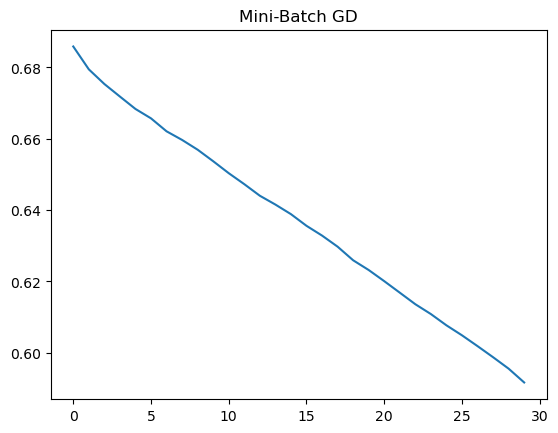

In [198]:
plt.plot(history.history['loss'])
plt.title("Mini-Batch GD")
plt.plot()